# Mid Semester Project - DEEP Reinforcements Learning
Dear students,<br> this is the template notebook. Please copy it by clicking on the "File" tab and then on "Save a copy into drive".

---
<br>

### Name and ID:
Student 1: Efi Pecani
<br>
Student 2: Adi Zur
<br><br>
<img src="https://raw.githubusercontent.com/Farama-Foundation/Minigrid/master/minigrid-text.png">

### https://minigrid.farama.org/

# Pre-Requisit

## Installs

In [ ]:
%%capture
!sudo apt-get update
!sudo apt-get install -y xvfb ffmpeg freeglut3-dev
!pip install 'imageio==2.4.0'
!apt-get install python-opengl -y
!apt install xvfb -y
!pip install pyvirtualdisplay
!pip install piglet
!pip install gymnasium
!apt-get install python-opengl -y
!apt install xvfb -y
!pip install -U --no-cache-dir gdown --pre
!pip install minigrid
!wget -q https://www.dropbox.com/scl/fi/jhkb2y3jw8wgin9e26ooc/MiniGrid-MultiRoom-N6-v0_vid.mp4?rlkey=qtkrmmbk9aiote5z7w4bx6ixi&st=zbr4gk21&dl=1 -O content/MiniGrid-MultiRoom-N6-v0_vid.mp4


## Imports

In [ ]:
from pyvirtualdisplay import Display
from IPython.display import HTML
from IPython import display as ipythondisplay
import pyvirtualdisplay
import IPython
import base64
import gymnasium
import minigrid
from minigrid.wrappers import RGBImgObsWrapper, RGBImgPartialObsWrapper, ImgObsWrapper, FullyObsWrapper, RGBImgPartialObsWrapper
import matplotlib.pyplot as plt
import imageio
import numpy as np
import cv2

In [ ]:
# Constants for the environemnt configuration do no change the values
highlight = False
render_mode = "rgb_array"

## Display utils
The cell below contains the video display configuration. No need to make changes here.

In [ ]:
def embed_mp4(filename):
  """Embeds an mp4 file in the notebook."""
  video = open(filename,'rb').read()
  b64 = base64.b64encode(video)
  tag = '''
  <video width="640" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
  Your browser does not support the video tag.
  </video>'''.format(b64.decode())

  return IPython.display.HTML(tag)
display = pyvirtualdisplay.Display(visible=0, size=(1400, 900)).start()

# Introduction

For this project, you will work with environments from the [MiniGrid](https://minigrid.farama.org) framework. MiniGrid is designed to test and benchmark reinforcement learning algorithms, offering a diverse range of tasks with varying levels of complexity.

MiniGrid environments are built around the concept of a partially observable, grid-based world where an agent operates to achieve predefined objectives.

## **MultiRoom Environment**

You will work with the **MultiRoom Environment** see docomentation [here](https://minigrid.farama.org/environments/minigrid/MultiRoomEnv/). MultiRoomEnv introduces a level of complexity beyond simple navigation tasks by requiring the agent to navigate through multiple connected rooms to reach a goal. This environment is an excellent testbed for reinforcement learning algorithms that require exploration, memory, and planning.



## Understanding the `done` and `truncated` Mechanisms in MultiRoomEnv

As you experienced in the MidTerm assignment, the **GYM** API returns multiple outputs from the **`step`** method. In the MultiRoomEnv environment, two key mechanisms, **`done`** and **`truncated`**, are used to signify the end of an episode. These mechanisms are essential for managing the flow of training and providing valuable feedback about the agent's performance.


### `done`
- The `done` flag is set to `True` when the agent successfully reaches the goal.
- It indicates the successful termination of the episode, meaning the agent has completed the task.
- Example scenario: The agent navigates through all the rooms and reaches the green goal square in the final room.

### `truncated`
- The `truncated` flag is used to terminate an episode when a predefined condition is met, such as exceeding the maximum number of steps allowed.
- It does not necessarily indicate success or failure, but rather ensures that episodes do not run indefinitely.
- Example scenario: The agent fails to reach the goal within the allowed number of steps, and the episode ends prematurely.

**Pay Attention!**

Each time the environment is reset, the configuration of the rooms is randomized. This variability should be carefully considered during training, as resetting the environment every time the `max_step` limit is reached can make it challenging for the agent to learn effectively.

Additionally, note that the `max_step` parameter is defined as the number of rooms multiplied by 20.


## Random Action Rendering

In [ ]:
env = gymnasium.make("MiniGrid-MultiRoom-N6-v0", render_mode=render_mode, highlight=highlight)
video_filename = '/content/vid.mp4'
truncated = False
# Evaluation
with imageio.get_writer(video_filename, fps=16) as video:
  obs, _ = env.reset()
  done = False
  total_reward = 0
  step = 0
  while not truncated:
      action = env.action_space.sample()
      obs, reward, done, truncated  , _ = env.step(action)
      next_obs = obs  # Get agent's position directly from the environment
      video.append_data(env.render())
      step += 1
      if truncated:
        print("done","reward=", total_reward,"num_of_steps=",step)
        break
embed_mp4(video_filename)

done reward= 0 num_of_steps= 120


## Wrappers for Observations: ImgObsWrapper and RGBImgPartialObsWrapper

For this project, you will use two wrappers provided by MiniGrid: **ImgObsWrapper** and **RGBImgPartialObsWrapper**. These wrappers modify the agent's observations.

### ImgObsWrapper
- The **ImgObsWrapper** converts the observation from its default dictionary format into a single image array.
- By default, observations in MiniGrid are returned as a dictionary containing both image data and other optional keys (e.g., mission strings). This wrapper extracts only the image component for simplicity.

### RGBImgPartialObsWrapper
- This wrapper provides a **partial view of the environment**, but instead of limiting it to a fixed field of view, it shows the **entire visible content of the current room** from the agent's position to the walls in the direction the agent is facing.
- The observation dynamically updates as the agent moves or turns, allowing it to see the layout of the room but not beyond its walls or through closed doors.
- This introduces the challenge of **partial observability across multiple rooms**, as the agent must explore and navigate to new rooms to gather more information about the environment.





### Wrapper Usage
To apply a wrapper, you can modify your environment setup as follows:

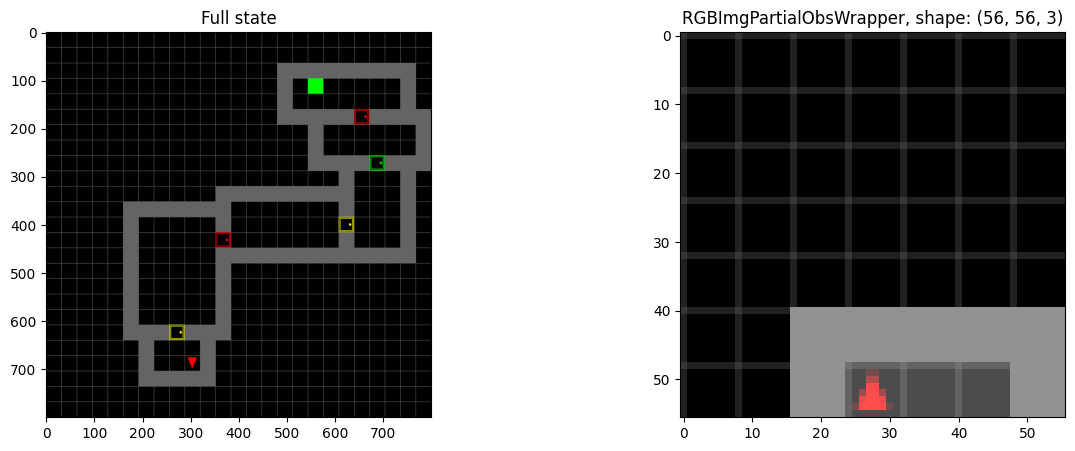

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
env = gymnasium.make("MiniGrid-MultiRoom-N6-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)
obs, _ = env.reset()
axs[1].imshow(obs)
axs[1].title.set_text(f'RGBImgPartialObsWrapper, shape: {obs.shape}')
axs[0].imshow(env.render())
axs[0].title.set_text(f'Full state')
plt.show()

## Initializing the smaller environments

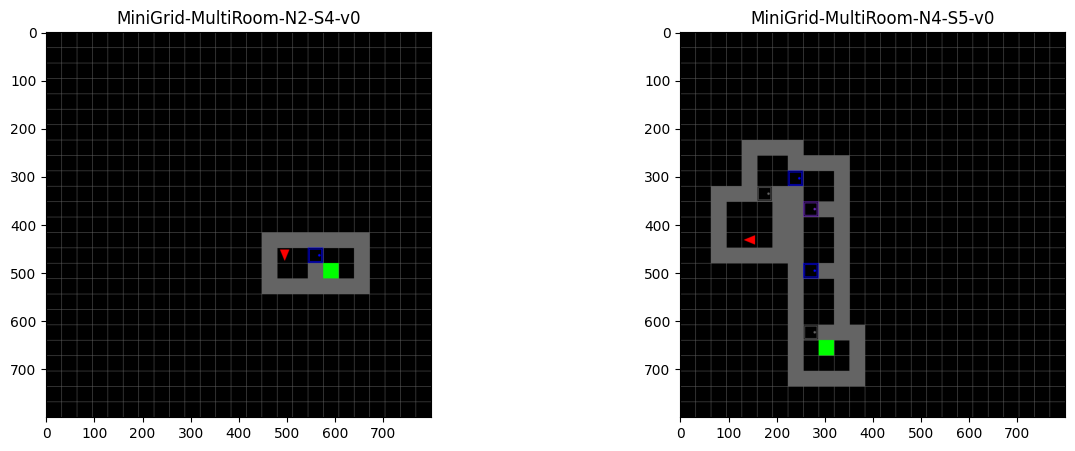

In [ ]:
env = gymnasium.make("MiniGrid-MultiRoom-N2-S4-v0", render_mode=render_mode, highlight=highlight)
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)
obs, _ = env.reset()
axs[0].imshow(env.render())
axs[0].title.set_text(f'MiniGrid-MultiRoom-N2-S4-v0')



env = gymnasium.make("MiniGrid-MultiRoom-N4-S5-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)
obs, _ = env.reset()
axs[1].imshow(env.render())
axs[1].title.set_text(f'MiniGrid-MultiRoom-N4-S5-v0')
plt.show()

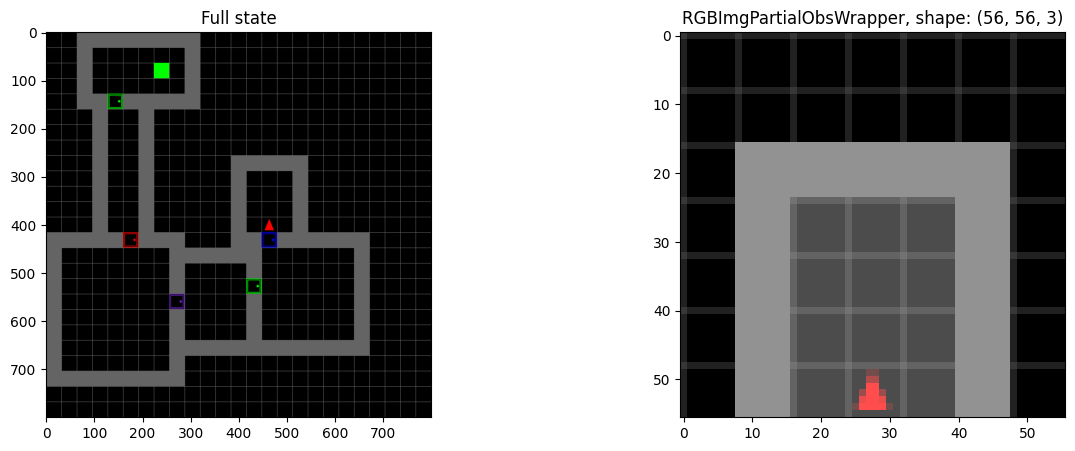

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
env = gymnasium.make("MiniGrid-MultiRoom-N6-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)
obs, _ = env.reset()
axs[1].imshow(obs)
axs[1].title.set_text(f'RGBImgPartialObsWrapper, shape: {obs.shape}')
axs[0].imshow(env.render())
axs[0].title.set_text(f'Full state')
plt.show()

### Partial Observation Example

In [ ]:
env = gymnasium.make("MiniGrid-MultiRoom-N6-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)
video_filename = '/content/vid_partial.mp4'
truncated = False
# Evaluation
with imageio.get_writer(video_filename, fps=10) as video:
  obs, _ = env.reset()
  done = False
  total_reward = 0
  step = 0
  while not truncated:
      action = env.action_space.sample()
      obs, reward, done, truncated  , _ = env.step(action)
      next_obs = obs  # Get agent's position directly from the environment
      video.append_data(obs)
      step += 1
      if truncated:
        print("done","reward=", total_reward,"num_of_steps=",step)
        break
embed_mp4(video_filename)

done reward= 0 num_of_steps= 120


## Exmple from our solution

In [ ]:
# Step 1: Correct download path
# Call the function
embed_mp4('MiniGrid-MultiRoom-N6-v0_vid.mp4?rlkey=qtkrmmbk9aiote5z7w4bx6ixi')


# Your Code here ...

# Agent Setup

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Set device
print(f"Using device: {device}")  # Check if CUDA is available

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
import collections
from collections import deque
import random
import pickle
from tqdm import tqdm
from google.colab import drive
drive.mount('/content/drive')
import os
import re

Using device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Epsilon Decay

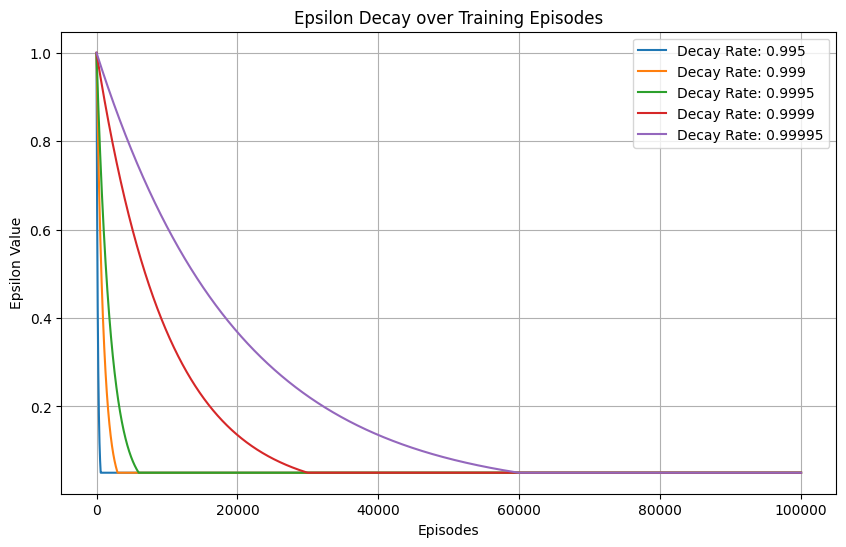

In [ ]:
# Parameters
episodes = 100000  # Total training episodes
epsilon_min = 0.05  # Minimum epsilon value
decay_rates = [0.995, 0.999, 0.9995, 0.9999, 0.99995]  # Different decay rates
initial_epsilon = 1.0  # Starting epsilon

# Generate epsilon decay curves
plt.figure(figsize=(10, 6))
for decay in decay_rates:
    epsilon_values = []
    epsilon = initial_epsilon
    for episode in range(episodes):
        epsilon = max(epsilon_min, epsilon * decay)
        epsilon_values.append(epsilon)

    plt.plot(range(episodes), epsilon_values, label=f"Decay Rate: {decay}")

plt.xlabel("Episodes")
plt.ylabel("Epsilon Value")
plt.title("Epsilon Decay over Training Episodes")
plt.legend()
plt.grid()
plt.show()

## CNN Architecture

In [ ]:
class DuelingDDQN_NN(nn.Module):
    def __init__(self, action_dim):
        super(DuelingDDQN_NN, self).__init__()

        # Shared convolutional layers for feature extraction
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1),  # 1st Conv layer --> input: 1 channel, output: 32 channels
            nn.ReLU(), # Activation function
            nn.Conv2d(32, 64, kernel_size=3, stride=1), # 2nd Conv layer --> input: 32 channel, output: 64 channels
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=1), # 3rd Conv layer --> input: 64 channel, output: 128 channels
            nn.ReLU(),
            nn.Flatten()
        )

        # Advantage stream - A(s, a)
        self.fc_adv = nn.Sequential(
            nn.Linear(128 * 8 * 8, 256), # Fully connected layer
            nn.ReLU(),
            nn.Linear(256, action_dim) # Output Q-value estimate for each possible action the agent can take
        )

        # Value stream - V(s)
        self.fc_val = nn.Sequential(
            nn.Linear(128 * 8 * 8, 256), # Fully connected layer
            nn.ReLU(),
            nn.Linear(256, 1)  # Output single value for state

        )

    def forward(self, x):
        features = self.conv_layers(x)  # Shared feature extraction

        adv = self.fc_adv(features)  # Advantage stream
        val = self.fc_val(features)  # Value stream

        # Combine value and advantage streams
        q_values = val + (adv - adv.mean(dim=1, keepdim=True)) # Q(s,a) = V(s) + A(s) - mean(A(s))
        return q_values

## Replay Buffer

In [ ]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = collections.deque(maxlen=capacity) # Stores experiences

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done)) # Add experience to the buffer

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size) # Randomly select a batch of experiences
        states, actions, rewards, next_states, dones = zip(*batch) # Unpack batch into separate lists

        return (
            torch.tensor(np.array(states), dtype=torch.float32).to(device), # Convert states to tensor
            torch.tensor(actions, dtype=torch.int64).to(device), # Convert actions to tensor
            torch.tensor(rewards, dtype=torch.float32).to(device), # Convert rewards to tensor
            torch.tensor(np.array(next_states), dtype=torch.float32).to(device), # Convert next states to tensor
            torch.tensor(dones, dtype=torch.float32).to(device) # Convert done flags to tensor
        )

    def __len__(self):
        return len(self.buffer) # Return the current buffer size

## Reward Shaping

In [ ]:
class RewardShaping:
    def __init__(self):
        self.visited_positions = set() # Set of positions the agent has visited
        self.doors = {} # Dictionary to store doors positions and if they opened
        self.recent_actions = deque(maxlen=5)  # Track last 5 actions
        self.last_door_opened = False # Track if the last action opened a new door
        self.toggle_count = 0 # Count consecutive toggle actions
        self.grid_size = 60 # Grid size of the environment
        self.agent_pos = (30,30) # Initial agent position
        self.agent_dir = 0 # Initial agent direction (0: Up, 1: Right, 2: Down, 3: Left)

    def reset(self):
        self.visited_positions.clear()
        self.doors.clear()
        self.recent_actions.clear()
        self.last_door_opened = False
        self.toggle_count = 0
        self.agent_pos = (30,30)
        self.agent_dir = 0

    def get_agent_position(self, action, previous_state, next_state):
        x, y = self.agent_pos # Get current position

        if action == 2: # Move forward
          if not self.detect_state_change(previous_state, next_state):
            return (x,y) # Do not move if no state change detected (wall or closed door)

          # Update position based on direction
          elif self.agent_dir == 0:
            y = max(0, y - 1) # Move up
          elif self.agent_dir == 1:
            x = min(self.grid_size - 1, x + 1) # Move right
          elif self.agent_dir == 2:
            y = min(self.grid_size - 1, y + 1) # Move down
          elif self.agent_dir == 3:
            x = max(0, x - 1) # Move left


        elif action == 0: # Turn left
          self.agent_dir = (self.agent_dir - 1) % 4

        elif action == 1: # Turn right
          self.agent_dir = (self.agent_dir + 1) % 4

        return (x, y)

    def detect_state_change(self, previous_state, next_state):
        green_diff = np.abs(next_state[:, :, 1] - previous_state[:, :, 1])  # Extract green channel difference
        threshold = 10  # Define change threshold
        return np.sum(green_diff) > threshold # Return True if change is above threshold

    def doors_per_episode(self):
        return len(self.doors) # Return the number of doors opened so far

    def compute_shaped_reward(self, env_reward, done, env, action, previous_state, next_state):
        shaped_reward = env_reward  # Start with the original environment reward

        self.agent_pos = self.get_agent_position(action, previous_state, next_state) # Update agent position based on the action

        self.recent_actions.append(action) # Add recent action

        # Determine optional door position based on agent direction
        if self.agent_dir == 0:  # Facing up
            door_pos = (self.agent_pos[0], self.agent_pos[1] - 1)
        elif self.agent_dir == 1:  # Facing right
            door_pos = (self.agent_pos[0] + 1, self.agent_pos[1])
        elif self.agent_dir == 2:  # Facing down
            door_pos = (self.agent_pos[0], self.agent_pos[1] + 1)
        elif self.agent_dir == 3:  # Facing left
            door_pos = (self.agent_pos[0] - 1, self.agent_pos[1])

        if self.agent_pos not in self.visited_positions:
            self.visited_positions.add(self.agent_pos)
            shaped_reward += 0.05  # Small reward for exploration
            # shaped_reward += 0.1  # Small reward for exploration

        if action == 2 and self.last_door_opened:
          shaped_reward += 0.2 # Reward for moving forward after opening a door

        # Track toggling actions
        if action == 3:
            self.toggle_count += 1
        else:
            self.toggle_count = 0

        # Check if the agent is on a door (indicating a new room entry)
        if action == 3 and self.detect_state_change(previous_state, next_state):
          if door_pos not in self.doors: # First time opening a door
            shaped_reward += 0.5 # Reward for opening a new door
            self.doors[door_pos] = True
            self.last_door_opened = True
          else:
            shaped_reward -= 0.3 # Penalize unnecessary toggling

        if self.toggle_count > 2:
            shaped_reward -= 0.2  # Penalize excessive toggling

        if len(self.recent_actions) > 3 and len(set(list(self.recent_actions)[-4:])) == 1:
            shaped_reward -= 0.1 # Penalize repeated action sequences

        if action in [0, 1, 2]:
          self.last_door_opened = False # Reset last_door_opened flag if agent is not toggling

        if done:
            shaped_reward += 3.0 # Large reward for successfully reaching the goal

        return shaped_reward

## Dueling DDQN Agent

In [ ]:
class DuelingDoubleDQNAgent:
    def __init__(self, env, learning_rate, gamma, epsilon_decay, training_episodes):
        self.env = env
        self.action_dim = 4
        self.gamma = gamma
        self.batch_size = 64
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.start_episode = 0
        self.epsilon_decay = epsilon_decay
        self.training_episodes = training_episodes
        self.target_update_freq = 10000
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # For training analysis
        self.total_rewards = []
        self.total_steps = []
        self.success_rates = []
        self.train_success = 0 # Counter for successful traning episodes
        self.action_counts = {0: 0, 1: 0, 2: 0, 3: 0}
        self.episode_door_n = []

        self.losses = []
        self.reverse_action_mapping = {0: 0, 1: 1, 2: 2, 3: 5}  # Convert 3 → 5 for env execution

        # Reward shaping
        self.reward_shaper = RewardShaping()

        # Initialize networks
        self.model_net = DuelingDDQN_NN(self.action_dim).to(self.device)
        self.target_net = DuelingDDQN_NN(self.action_dim).to(self.device)
        self.target_net.load_state_dict(self.model_net.state_dict())  # Sync target net

        self.optimizer = optim.Adam(self.model_net.parameters(), lr=learning_rate)
        self.replay_buffer = ReplayBuffer(capacity=10000)

        self.model_update_counter = 0 # Training step counter

    def preprocess_image(self, state):
        green_channel_state = state[:, :, 1] # Extract the green channel - target is in green

        resized_state = cv2.resize(green_channel_state, (14, 14), interpolation=cv2.INTER_AREA) # Resize image from 56x56 to 14x14

        preprocess_state = resized_state

        return torch.tensor(preprocess_state, dtype=torch.float32).unsqueeze(0).to(self.device) / 255.0  # Shape: [1, 14, 14]

    def select_action(self, state):
        if random.random() < self.epsilon:
          action = random.choice([0, 1, 2, 3])  # Random action (exploration)

        else:
          with torch.no_grad():
            action = self.model_net(state.unsqueeze(0)).argmax().item() # Best action (exploitation)

        return action

    def model_update(self):
        if len(self.replay_buffer) < self.batch_size:
            return  # Wait until enough samples

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(self.batch_size) # Sample from buffer

        states = states.to(self.device)
        actions = actions.to(self.device)
        rewards = rewards.to(self.device)
        next_states = next_states.to(self.device)
        dones = dones.to(self.device)

        q_values = self.model_net(states).gather(1, actions.unsqueeze(1)).squeeze(1) # Compute current Q-values

        # Compute Double DDQN target Q-values
        with torch.no_grad():
            next_action_selection = self.model_net(next_states).argmax(dim=1)  # Select best action
            next_q_values = self.target_net(next_states).gather(1, next_action_selection.unsqueeze(1)).squeeze(1)
            target_q_values = rewards + (self.gamma * next_q_values * (1 - dones))

        loss = nn.MSELoss()(q_values, target_q_values) # Compute loss

        # Backpropagate
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Update target network periodically
        if self.model_update_counter % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.model_net.state_dict())

        self.model_update_counter += 1

        return loss.item()

    def train(self):
      progress_bar = tqdm(total=self.training_episodes, desc="Training Progress", unit="episode", leave=True)

      for episode in range(self.start_episode, self.training_episodes):
        state, _ = self.env.reset() # Reset environment
        truncated = False
        total_reward = 0
        step = 0
        self.reward_shaper.reset() # Reset reward shaping history
        episode_losses = []

        while not truncated:
          preprocess_state = self.preprocess_image(state) # Preprocess the state

          action = self.select_action(preprocess_state) # Select an action
          self.action_counts[action] += 1 # Track the number of times each action is chosen

          next_state, reward, done, truncated, _ = self.env.step(self.reverse_action_mapping[action])  # Execute the selected action in the environment

          reward = self.reward_shaper.compute_shaped_reward(reward, done, self.env, action, state, next_state) # Compute the shaped reward

          preprocess_next_state = self.preprocess_image(next_state) # Preprocess the next state

          self.replay_buffer.push(preprocess_state.cpu().numpy(), action, reward, preprocess_next_state.cpu().numpy(), done) # Store experience in the replay buffer

          loss = self.model_update() # Update the model
          if loss is not None:
            episode_losses.append(loss)

          # Move to the next state
          state = next_state
          total_reward += reward
          step += 1

          if done:
            self.train_success += 1
            break

        # Store episode statistics for later analysis
        self.total_rewards.append(total_reward)
        self.total_steps.append(step)
        sucess_rate = self.train_success / (episode + 1)
        self.success_rates.append(sucess_rate)
        avg_loss = np.mean(episode_losses) if episode_losses and len(episode_losses) > 0 else 0
        self.losses.append(np.mean(episode_losses))
        self.episode_door_n.append(self.reward_shaper.doors_per_episode())

        if len(self.total_rewards) >= 1000:
          running_avg_reward = np.mean(self.total_rewards[-1000:])
          running_avg_doors = np.mean(self.episode_door_n[-1000:])
        else:
          running_avg_reward = np.mean(self.total_rewards)
          running_avg_doors = np.mean(self.episode_door_n)

        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay) # Decay epsilon for exploration

        progress_bar.update(1)
        progress_bar.set_postfix({"Progress": f"{(episode / self.training_episodes) * 100:.1f}%"})

        # Print training progress
        if episode % 1000 == 0 or episode == self.training_episodes -1:
          print(f"Episode {episode}, Running Avg Reward: {running_avg_reward}, Epsilon: {self.epsilon:.4f}, Doors Opened: {running_avg_doors}")

        # Save model every 1000 episodes
        if episode % 1000 == 0 or episode == self.training_episodes - 1:
          self.save_backup("/content/drive/MyDrive/MLDS/RL/final/", episode)
          if episode % 2000 == 0:
            print(f"Backup saved at {episode} episodes")

      progress_bar.close()

    def save_backup(self, path, episode):
      """
      Save the model and all training parameters for resuming training
      """
      backup_filename = f"backup_ep_{episode}.pkl"
      backup_path = os.path.join(path, backup_filename)

      backup_checkpoint = {
          'model_state_dict': self.model_net.state_dict(),
          'target_state_dict': self.target_net.state_dict(),
          'optimizer_state_dict': self.optimizer.state_dict(),
          'replay_buffer': self.replay_buffer,
          'episode': episode,
          'epsilon': self.epsilon,
          'train_success': self.train_success,
          'model_update_counter': self.model_update_counter,
          'total_rewards': self.total_rewards,
          'total_steps': self.total_steps,
          'success_rates': self.success_rates,
          'action_counts': self.action_counts,
          'total_losses': self.losses,
          'doors_per_episode': self.episode_door_n
      }

      with open(backup_path, 'wb') as f:
        pickle.dump(backup_checkpoint, f)

    def load_backup(self, backup_filename):
      """
      Load model and training state to resume training
      """
      backup_path = f"/content/drive/MyDrive/MLDS/RL/final/{backup_filename}"

      with open(backup_path, 'rb') as f:
        backup_checkpoint = pickle.load(f)

      self.model_net.load_state_dict(backup_checkpoint['model_state_dict'])
      self.target_net.load_state_dict(backup_checkpoint['target_state_dict'])
      self.optimizer.load_state_dict(backup_checkpoint['optimizer_state_dict'])
      self.replay_buffer = backup_checkpoint['replay_buffer']
      self.epsilon = backup_checkpoint['epsilon']
      self.train_success = backup_checkpoint['train_success']
      self.model_update_counter = backup_checkpoint['model_update_counter']
      self.total_rewards = backup_checkpoint['total_rewards']
      self.total_steps = backup_checkpoint['total_steps']
      self.success_rates = backup_checkpoint['success_rates']
      self.action_counts = backup_checkpoint['action_counts']
      self.total_losses = backup_checkpoint['total_losses']
      self.start_episode = backup_checkpoint['episode']
      self.episode_door_n = backup_checkpoint['doors_per_episode']

    def save_model(self, path):
      """
      Saves the model parameters.
      """
      with open(path, "wb") as f:
        pickle.dump(self.model_net.state_dict(), f)
      print(f"Model parameters saved successfully to {path}")

    def load_model(self, path):
      """
      Loads the model parameters.
      """
      with open(path, "rb") as f:
        self.model_net.load_state_dict(pickle.load(f))
      self.target_net.load_state_dict(self.model_net.state_dict())
      print(f"Model parameters loaded successfully from {path}")

    def test_model(self, num_episodes = 5, video_name = ''):
      self.model_net.eval()  # Set the model to evaluation mode (disables gradient updates)
      video_filename = f'test_model_{video_name}.mp4'
      total_rewards = []
      total_steps = []
      success = 0 # Count successful episodes

      for episode in range(num_episodes):
        with imageio.get_writer(video_filename, fps=24) as video:
          state, _ = self.env.reset() # Reset environment
          truncated = False
          episode_reward = 0
          episode_step = 0

          while not truncated:
            preprocess_state = self.preprocess_image(state).to(self.device).unsqueeze(0) # Preprocess the current state

            with torch.no_grad():
              action = self.model_net(preprocess_state).argmax().item() # Select the best action using the trained model
            env_action = self.reverse_action_mapping[action]

            next_state, reward, done, truncated, _ = self.env.step(env_action) # Execute the action in the environment

            state = next_state # Update the state

            video.append_data(env.render())
            episode_reward += reward
            episode_step += 1

            if done:
              success += 1
              break

          total_rewards.append(episode_reward)
          total_steps.append(episode_step)

          print(f"Episode {episode} - Reward: {episode_reward}, Steps {episode_step}")
          print("-"*50)

      print(f"Number of success episodes: {success} out of {num_episodes}")

# Training Analysis Plots

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def train_analysis(rewards_list, steps_list, success_rates, action_counts, N):
    window_size = max(10, int(0.02 * N))  # Window size for runnig average

    # Plot 1: Rewards vs Episodes
    plt.figure(figsize=(12, 6))
    rewards_running_avg = np.convolve(rewards_list, np.ones(window_size) / window_size, mode='valid')
    plt.plot(range(len(rewards_list)), rewards_list, label='Reward')
    plt.plot(range(window_size - 1, len(rewards_running_avg) + window_size - 1), rewards_running_avg,
             label='Running Average', color='r', linestyle='-')
    plt.title('Rewards Over Time')
    plt.xlabel('Episodes')
    plt.ylabel('Rewards')
    plt.legend()
    plt.show()

    # Plot 2: Steps vs Episodes
    plt.figure(figsize=(12, 6))
    steps_running_avg = np.convolve(steps_list, np.ones(window_size) / window_size, mode='valid')
    plt.plot(range(len(steps_list)), steps_list)
    plt.plot(range(window_size - 1, len(steps_running_avg) + window_size - 1), steps_running_avg,
             label='Running Average', color='r', linestyle='-')
    plt.title('Number of Steps per Episode')
    plt.xlabel('Episodes')
    plt.ylabel('Steps')
    plt.legend()
    plt.show()

    # Plot 3: Success Rate Over Time
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(success_rates)), success_rates, label='Cumulative Success Rate', color='g')
    plt.title('Success Rate Over Time')
    plt.xlabel('Episodes')
    plt.ylabel('Success Rate')
    plt.legend()
    plt.show()

    # Plot 4: Action Distribution
    plt.figure(figsize=(12, 6))
    plt.bar(action_counts.keys(), action_counts.values(), color='c')
    plt.title('Action Distribution')
    plt.xlabel('Actions')
    plt.xticks([0, 1, 2, 3])
    plt.legend(['Action Count'])
    plt.show()

# Training

## 2 Small Rooms Env

In [ ]:
env = gymnasium.make("MiniGrid-MultiRoom-N2-S4-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)

learning_rate = 0.0005
gamma = 0.95
epsilon_decay = 0.99995
training_episodes = 60000

In [ ]:
DDDQN_agent = DuelingDoubleDQNAgent(env, learning_rate, gamma, epsilon_decay, training_episodes)

DDDQN_agent.train()
DDDQN_agent.save_model("/content/drive/MyDrive/MLDS/RL/final/train_2SmallRooms_60000.pkl")
train_analysis(DDDQN_agent.total_rewards, DDDQN_agent.total_steps, DDDQN_agent.success_rates,DDDQN_agent.action_counts, training_episodes)

Training Progress:   0%|          | 0/60000 [00:00<?, ?episode/s]/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
Training Progress:   0%|          | 1/60000 [00:00<2:12:41,  7.54episode/s, Progress=0.0%]

Episode 0, Running Avg Reward: 0.4000000000000001, Epsilon: 1.0000, Doors Opened: 1.0
Backup saved at 0 episodes


Training Progress:   2%|▏         | 1001/60000 [04:47<4:28:42,  3.66episode/s, Progress=1.7%]

Episode 1000, Running Avg Reward: 0.24991249999999998, Epsilon: 0.9512, Doors Opened: 0.452


Training Progress:   3%|▎         | 2001/60000 [09:29<4:24:29,  3.65episode/s, Progress=3.3%]

...

Training Progress: 100%|██████████| 60000/60000 [2:05:11<00:00, 13.79episode/s, Progress=100.0%]

Episode 59999, Running Avg Reward: 2.4328175, Epsilon: 0.0500, Doors Opened: 0.994


Training Progress: 100%|██████████| 60000/60000 [2:05:11<00:00,  7.99episode/s, Progress=100.0%]

Model parameters saved successfully to /content/drive/MyDrive/MLDS/RL/final/train_2SmallRooms_60000.pkl


AttributeError: 'DuelingDoubleDQNAgent' object has no attribute 'doors_opened_per_episode'

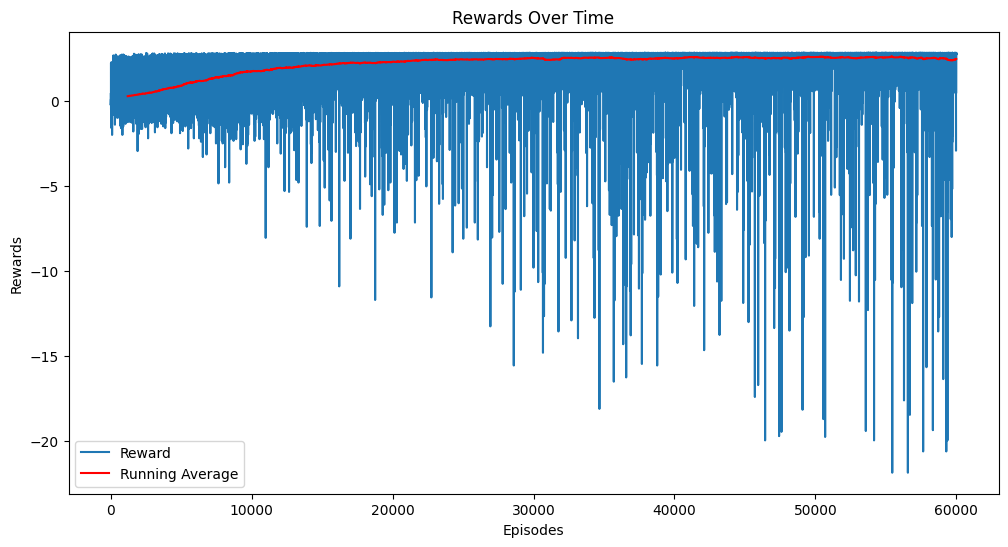

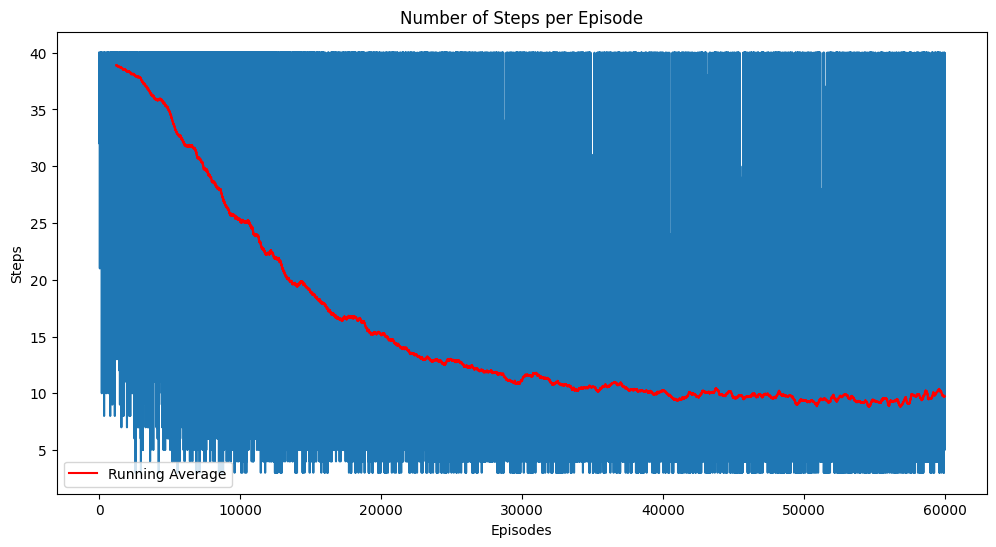

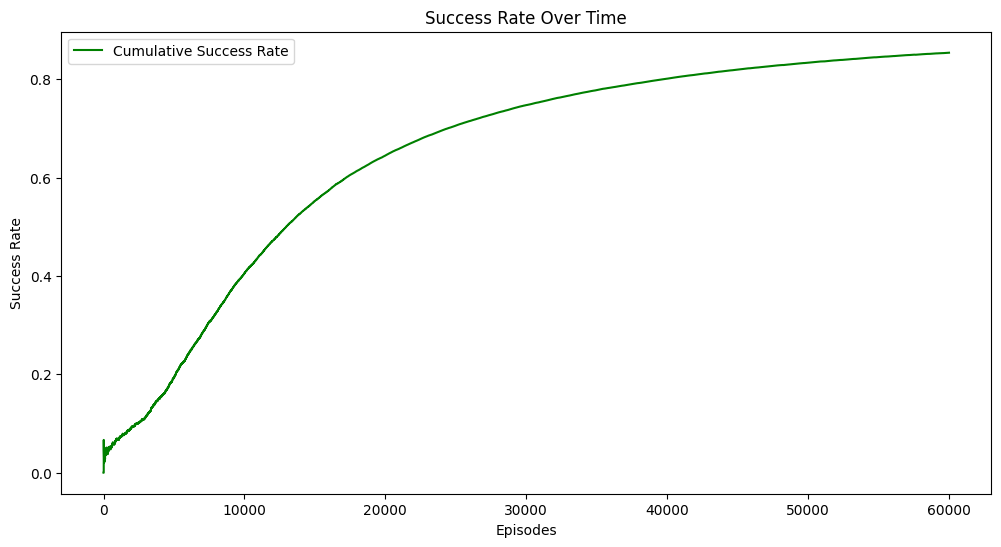

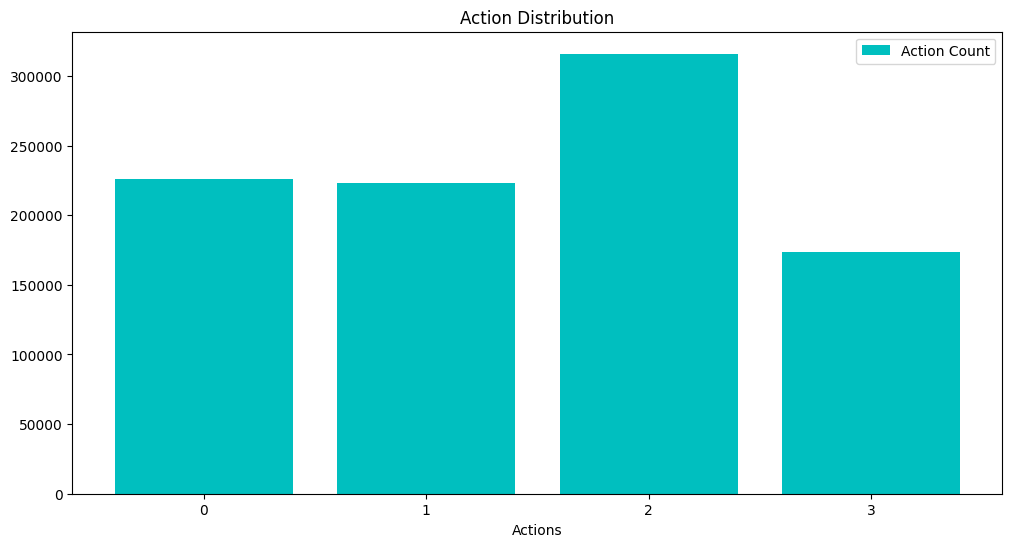

In [ ]:
train_analysis(DDDQN_agent.total_rewards, DDDQN_agent.total_steps, DDDQN_agent.success_rates,DDDQN_agent.action_counts, training_episodes)

In [ ]:
env = gymnasium.make("MiniGrid-MultiRoom-N2-S4-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)

test_agent = DuelingDoubleDQNAgent(env, learning_rate = 0.0005, gamma = 0.95, epsilon_decay = 0.99995, training_episodes = 60000)

test_agent.load_model("/content/drive/MyDrive/MLDS/RL/final/train_2SmallRooms_60000.pkl")

test_agent.test_model(num_episodes = 1, video_name = 'train_2SmallRooms_60000')

video_filename = 'test_model_train_2SmallRooms_60000.mp4'
embed_mp4(video_filename)

Model parameters loaded successfully from /content/drive/MyDrive/MLDS/RL/final/train_2SmallRooms_60000.pkl
Episode 0 - Reward: 0.7525, Steps 11
--------------------------------------------------
Number of success episodes: 1 out of 1


## 6 Small Rooms Env

In [ ]:
env = gymnasium.make("MiniGrid-MultiRoom-N4-S5-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)

learning_rate = 0.0005
gamma = 0.95
epsilon_decay = 0.99995
training_episodes = 80000

DDDQN_agent = DuelingDoubleDQNAgent(env, learning_rate, gamma, epsilon_decay, training_episodes)

In [ ]:
DDDQN_agent.load_model("/content/drive/MyDrive/MLDS/RL/final/train_2SmallRooms_60000.pkl")

DDDQN_agent.train()
DDDQN_agent.save_model("/content/drive/MyDrive/MLDS/RL/final/train_6SmallRooms_80000.pkl")
train_analysis(DDDQN_agent.total_rewards, DDDQN_agent.total_steps, DDDQN_agent.success_rates,DDDQN_agent.action_counts, training_episodes)

Model parameters loaded successfully from /content/drive/MyDrive/MLDS/RL/final/train_2SmallRooms_60000.pkl


Training Progress:   0%|          | 1/80000 [00:01<40:04:11,  1.80s/episode, Progress=0.0%]

Episode 0, Running Avg Reward: 0.7000000000000001, Epsilon: 1.0000, Doors Opened: 1.0
Backup saved at 0 episodes


Training Progress:   1%|▏         | 1001/80000 [14:15<18:04:29,  1.21episode/s, Progress=1.2%]

Episode 1000, Running Avg Reward: -0.07944999999999999, Epsilon: 0.9512, Doors Opened: 0.812


...

Training Progress:  43%|████▎     | 34001/80000 [7:40:00<4:58:32,  2.57episode/s, Progress=42.5%]

Episode 34000, Running Avg Reward: 5.842969999999999, Epsilon: 0.1827, Doors Opened: 4.697
Backup saved at 34000 episodes


Training Progress:  44%|████▍     | 35001/80000 [7:49:35<4:50:56,  2.58episode/s, Progress=43.8%]

Episode 35000, Running Avg Reward: 5.682399999999999, Epsilon: 0.1738, Doors Opened: 4.626


Training Progress:  45%|████▍     | 35776/80000 [7:57:07<6:50:04,  1.80episode/s, Progress=44.7%]

In [ ]:
# Continue from 35000 episodes
DDDQN_agent.load_backup("backup_ep_35000.pkl")

DDDQN_agent.train()
DDDQN_agent.save_model("/content/drive/MyDrive/MLDS/RL/final/train_6SmallRooms_80000.pkl")
train_analysis(DDDQN_agent.total_rewards, DDDQN_agent.total_steps, DDDQN_agent.success_rates,DDDQN_agent.action_counts, training_episodes)

Training Progress:   0%|          | 1/80000 [00:02<47:48:54,  2.15s/episode, Progress=43.8%]

Episode 35000, Running Avg Reward: 5.689424999999998, Epsilon: 0.1737, Doors Opened: 4.626


Training Progress:   1%|▏         | 1001/80000 [09:33<11:22:43,  1.93episode/s, Progress=45.0%]

Episode 36000, Running Avg Reward: 5.440859999999999, Epsilon: 0.1653, Doors Opened: 4.55
Backup saved at 36000 episodes


Training Progress:   3%|▎         | 2001/80000 [21:19<17:02:30,  1.27episode/s, Progress=46.2%]

...

Training Progress:  25%|██▌       | 20001/80000 [3:52:16<7:23:17,  2.26episode/s, Progress=68.8%]

Episode 55000, Running Avg Reward: 6.627759999999999, Epsilon: 0.0639, Doors Opened: 4.72


Training Progress:  26%|██▋       | 21001/80000 [3:59:56<9:08:14,  1.79episode/s, Progress=70.0%]

Episode 56000, Running Avg Reward: 6.3946425, Epsilon: 0.0608, Doors Opened: 4.708
Backup saved at 56000 episodes


Training Progress:  26%|██▋       | 21051/80000 [4:00:20<10:49:05,  1.51episode/s, Progress=70.1%]

Training Progress:   0%|          | 1/80000 [00:02<50:46:53,  2.29s/episode, Progress=70.0%]

Episode 56000, Running Avg Reward: 6.380132499999998, Epsilon: 0.0608, Doors Opened: 4.706
Backup saved at 56000 episodes


Training Progress:   1%|▏         | 1001/80000 [06:46<13:03:16,  1.68episode/s, Progress=71.2%]

Episode 57000, Running Avg Reward: 6.448722499999999, Epsilon: 0.0578, Doors Opened: 4.694


Training Progress:   3%|▎         | 2001/80000 [14:25<7:26:06,  2.91episode/s, Progress=72.5%]

...

Episode 79000, Running Avg Reward: 7.256444999999999, Epsilon: 0.0500, Doors Opened: 4.879


Training Progress:  30%|███       | 24000/80000 [2:42:32<6:48:05,  2.29episode/s, Progress=100.0%]

Episode 79999, Running Avg Reward: 7.2160625, Epsilon: 0.0500, Doors Opened: 4.84


Training Progress:  30%|███       | 24000/80000 [2:42:32<6:19:15,  2.46episode/s, Progress=100.0%]


Model parameters saved successfully to /content/drive/MyDrive/MLDS/RL/final/train_6SmallRooms_80000.pkl


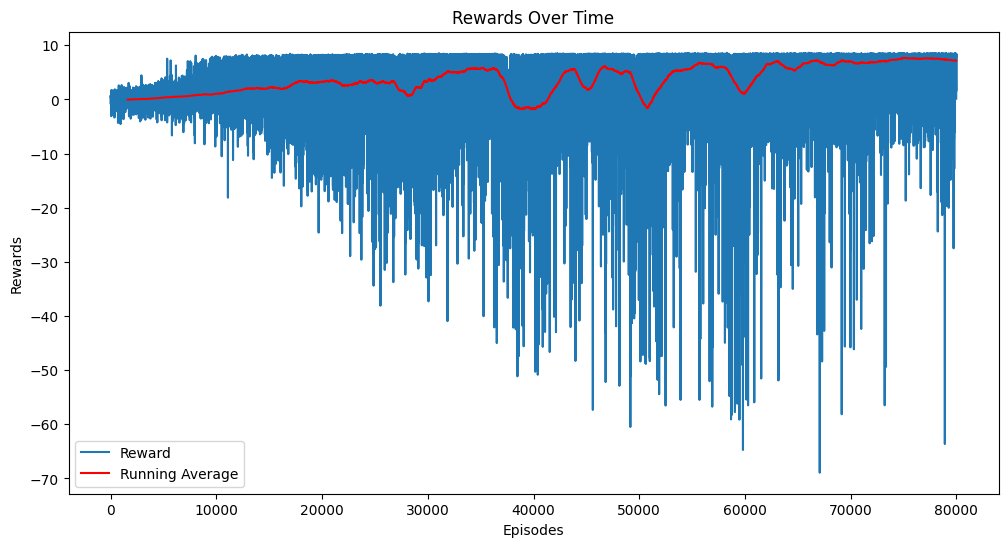

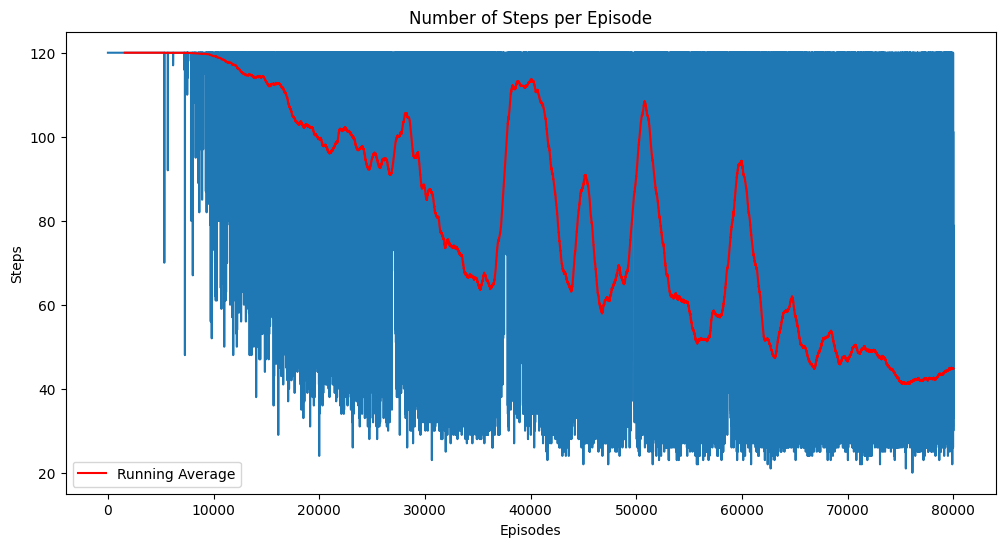

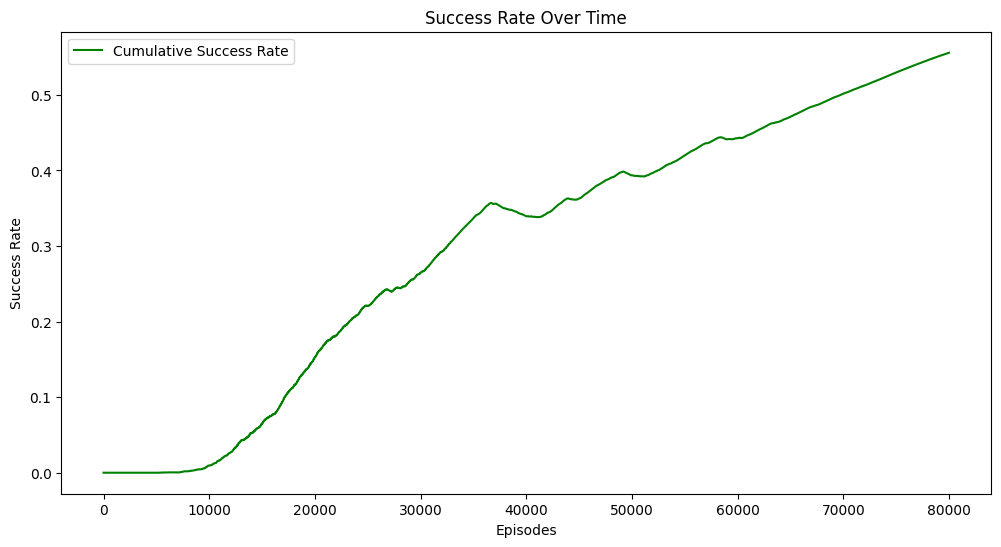

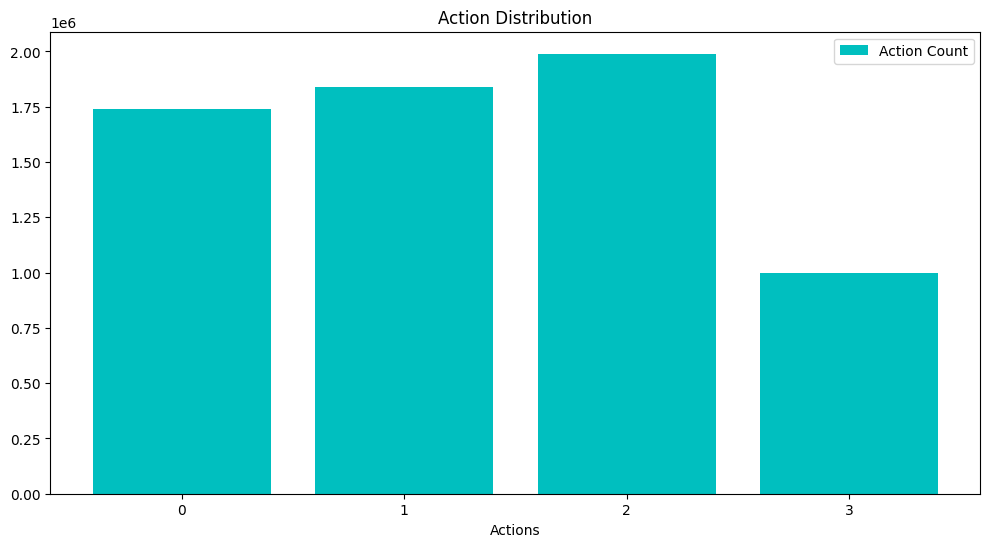

In [ ]:
# Continue from 56000 episodes
DDDQN_agent.load_backup("backup_ep_56000.pkl")

DDDQN_agent.train()
DDDQN_agent.save_model("/content/drive/MyDrive/MLDS/RL/final/train_6SmallRooms_80000.pkl")
train_analysis(DDDQN_agent.total_rewards, DDDQN_agent.total_steps, DDDQN_agent.success_rates,DDDQN_agent.action_counts, training_episodes)

In [ ]:
env = gymnasium.make("MiniGrid-MultiRoom-N4-S5-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)

test_agent = DuelingDoubleDQNAgent(env, learning_rate = 0.0005, gamma = 0.95, epsilon_decay = 0.99995, training_episodes = 80000)

test_agent.load_model("/content/drive/MyDrive/MLDS/RL/final/train_6SmallRooms_80000.pkl")

test_agent.test_model(num_episodes = 1, video_name = 'train_6SmallRooms_80000')

video_filename = 'test_model_train_6SmallRooms_80000.mp4'
embed_mp4(video_filename)

Model parameters loaded successfully from /content/drive/MyDrive/MLDS/RL/final/train_6SmallRooms_80000.pkl
Episode 0 - Reward: 0.7150000000000001, Steps 38
--------------------------------------------------
Number of success episodes: 1 out of 1


## 6 Rooms Env

In [ ]:
env = gymnasium.make("MiniGrid-MultiRoom-N6-v0", render_mode=render_mode, highlight=highlight)
env.unwrapped.max_steps = 100
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)

learning_rate = 0.0005
gamma = 0.95
epsilon_decay = 0.99995
training_episodes = 90000

DDDQN_agent = DuelingDoubleDQNAgent(env, learning_rate, gamma, epsilon_decay, training_episodes)

In [ ]:
DDDQN_agent.load_model("/content/drive/MyDrive/MLDS/RL/final/train_6SmallRooms_80000.pkl")

DDDQN_agent.train()
DDDQN_agent.save_model("/content/drive/MyDrive/MLDS/RL/final/train_6Rooms_100000.pkl")
train_analysis(DDDQN_agent.total_rewards, DDDQN_agent.total_steps, DDDQN_agent.success_rates,DDDQN_agent.action_counts, training_episodes)

Model parameters loaded successfully from /content/drive/MyDrive/MLDS/RL/final/train_6SmallRooms_80000.pkl


Training Progress:   0%|          | 1/100000 [00:00<19:20:08,  1.44episode/s, Progress=0.0%]

Episode 0, Running Avg Reward: 4.750000000000002, Epsilon: 1.0000, Doors Opened: 1.0
Backup saved at 0 episodes


Training Progress:   1%|          | 1001/100000 [11:49<19:49:24,  1.39episode/s, Progress=1.0%]

Episode 1000, Running Avg Reward: 0.7707000000000003, Epsilon: 0.9512, Doors Opened: 0.382


Training Progress:   2%|▏         | 2001/100000 [23:38<19:02:39,  1.43episode/s, Progress=2.0%]

Episode 2000, Running Avg Reward: 1.2497500000000001, Epsilon: 0.9048, Doors Opened: 0.505
Backup saved at 2000 episodes


Training Progress:   3%|▎         | 3001/100000 [35:30<20:05:24,  1.34episode/s, Progress=3.0%]

Episode 3000, Running Avg Reward: 1.6831500000000006, Epsilon: 0.8607, Doors Opened: 0.672


Training Progress:   4%|▎         | 3563/100000 [42:09<18:07:16,  1.48episode/s, Progress=3.6%]

In [ ]:
# Continue from 3000 episodes
DDDQN_agent.load_backup("backup_ep_3000.pkl")
DDDQN_agent.train()
DDDQN_agent.save_model("/content/drive/MyDrive/MLDS/RL/final/train_6Rooms_100000.pkl")
train_analysis(DDDQN_agent.total_rewards, DDDQN_agent.total_steps, DDDQN_agent.success_rates,DDDQN_agent.action_counts, training_episodes)

Training Progress:   0%|          | 1/100000 [00:03<87:20:57,  3.14s/episode, Progress=3.0%]

Episode 3000, Running Avg Reward: 1.6857500000000005, Epsilon: 0.8606, Doors Opened: 0.673


Training Progress:   1%|          | 1001/100000 [12:14<20:18:02,  1.35episode/s, Progress=4.0%]

Episode 4000, Running Avg Reward: 2.2722000000000007, Epsilon: 0.8186, Doors Opened: 0.83
Backup saved at 4000 episodes


Training Progress:   2%|▏         | 2001/100000 [24:18<19:48:28,  1.37episode/s, Progress=5.0%]

...

Training Progress:   8%|▊         | 8001/100000 [1:39:48<17:57:11,  1.42episode/s, Progress=11.0%]

Episode 11000, Running Avg Reward: 4.455750000000002, Epsilon: 0.5769, Doors Opened: 1.165


Training Progress:   9%|▉         | 9001/100000 [1:53:20<18:09:25,  1.39episode/s, Progress=12.0%]

Episode 12000, Running Avg Reward: 4.363650000000002, Epsilon: 0.5487, Doors Opened: 1.142
Backup saved at 12000 episodes


Training Progress:  10%|▉         | 9618/100000 [2:02:08<20:48:30,  1.21episode/s, Progress=12.6%]

In [ ]:
# Continue from 12000 episodes
DDDQN_agent.load_backup("backup_ep_12000.pkl")
DDDQN_agent.train()
DDDQN_agent.save_model("/content/drive/MyDrive/MLDS/RL/final/train_6Rooms_100000.pkl")
train_analysis(DDDQN_agent.total_rewards, DDDQN_agent.total_steps, DDDQN_agent.success_rates,DDDQN_agent.action_counts, training_episodes)

Training Progress:   0%|          | 1/100000 [00:02<60:11:28,  2.17s/episode, Progress=12.0%]

Episode 12000, Running Avg Reward: 4.369950000000001, Epsilon: 0.5487, Doors Opened: 1.143
Backup saved at 12000 episodes


Training Progress:   1%|          | 1001/100000 [12:27<21:38:20,  1.27episode/s, Progress=13.0%]

Episode 13000, Running Avg Reward: 4.839200000000002, Epsilon: 0.5220, Doors Opened: 1.175


Training Progress:   2%|▏         | 2001/100000 [24:54<19:25:35,  1.40episode/s, Progress=14.0%]

...

Training Progress:  37%|███▋      | 37001/100000 [7:42:12<12:17:39,  1.42episode/s, Progress=49.0%]

Episode 49000, Running Avg Reward: 10.218724999999997, Epsilon: 0.0863, Doors Opened: 3.056


Training Progress:  38%|███▊      | 38001/100000 [7:53:08<10:52:43,  1.58episode/s, Progress=50.0%]

Episode 50000, Running Avg Reward: 12.259821999999996, Epsilon: 0.0821, Doors Opened: 3.965
Backup saved at 50000 episodes


Training Progress:  38%|███▊      | 38380/100000 [7:57:12<10:53:21,  1.57episode/s, Progress=50.4%]

In [ ]:
# Continue from 50000 episodes
DDDQN_agent.load_backup("backup_ep_50000.pkl")

DDDQN_agent.train()
DDDQN_agent.save_model("/content/drive/MyDrive/MLDS/RL/final/train_6Rooms_100000.pkl")
train_analysis(DDDQN_agent.total_rewards, DDDQN_agent.total_steps, DDDQN_agent.success_rates,DDDQN_agent.action_counts, training_episodes)

Training Progress:   0%|          | 1/100000 [00:01<55:04:16,  1.98s/episode, Progress=50.0%]

Episode 50000, Running Avg Reward: 12.263057999999997, Epsilon: 0.0821, Doors Opened: 3.968
Backup saved at 50000 episodes


Training Progress:   1%|          | 1001/100000 [11:16<19:09:27,  1.44episode/s, Progress=51.0%]

Episode 51000, Running Avg Reward: 11.716014, Epsilon: 0.0781, Doors Opened: 3.919


Training Progress:   2%|▏         | 2001/100000 [22:25<16:37:49,  1.64episode/s, Progress=52.0%]

...

Episode 54000, Running Avg Reward: 11.669289, Epsilon: 0.0672, Doors Opened: 4.127
Backup saved at 54000 episodes


Training Progress:   5%|▌         | 5001/100000 [55:22<13:08:45,  2.01episode/s, Progress=55.0%]

Episode 55000, Running Avg Reward: 11.527500999999997, Epsilon: 0.0639, Doors Opened: 3.998


Training Progress:   5%|▌         | 5254/100000 [57:48<20:35:22,  1.28episode/s, Progress=55.3%]

KeyboardInterrupt: 

In [ ]:
# Continue from 55000 episodes
DDDQN_agent.load_backup("backup_ep_55000.pkl")

DDDQN_agent.train()
DDDQN_agent.save_model("/content/drive/MyDrive/MLDS/RL/final/train_6Rooms_100000.pkl")
train_analysis(DDDQN_agent.total_rewards, DDDQN_agent.total_steps, DDDQN_agent.success_rates,DDDQN_agent.action_counts, training_episodes)

Training Progress:   0%|          | 1/100000 [00:02<64:21:24,  2.32s/episode, Progress=55.0%]

Episode 55000, Running Avg Reward: 11.510301, Epsilon: 0.0639, Doors Opened: 3.997


Training Progress:   1%|          | 1001/100000 [10:40<19:52:58,  1.38episode/s, Progress=56.0%]

Episode 56000, Running Avg Reward: 11.575985999999999, Epsilon: 0.0608, Doors Opened: 4.076
Backup saved at 56000 episodes


Training Progress:   2%|▏         | 2001/100000 [22:16<19:40:59,  1.38episode/s, Progress=57.0%]

...

Episode 79000, Running Avg Reward: 12.244847999999998, Epsilon: 0.0500, Doors Opened: 4.341


Training Progress:  25%|██▌       | 25001/100000 [4:06:24<10:37:44,  1.96episode/s, Progress=80.0%]

Episode 80000, Running Avg Reward: 12.796779, Epsilon: 0.0500, Doors Opened: 4.493
Backup saved at 80000 episodes


Training Progress:  25%|██▌       | 25167/100000 [4:07:54<8:32:38,  2.43episode/s, Progress=80.2%]

KeyboardInterrupt: 

In [ ]:
# Continue from 80000 episodes
DDDQN_agent.load_backup("backup_ep_80000.pkl")

DDDQN_agent.train()
DDDQN_agent.save_model("/content/drive/MyDrive/MLDS/RL/final/train_6Rooms_100000.pkl")
train_analysis(DDDQN_agent.total_rewards, DDDQN_agent.total_steps, DDDQN_agent.success_rates,DDDQN_agent.action_counts, training_episodes)

Training Progress:   0%|          | 1/100000 [00:00<24:11:42,  1.15episode/s, Progress=80.0%]

Episode 80000, Running Avg Reward: 12.801741, Epsilon: 0.0500, Doors Opened: 4.496
Backup saved at 80000 episodes


Training Progress:   1%|          | 1001/100000 [11:52<19:09:42,  1.44episode/s, Progress=81.0%]

Episode 81000, Running Avg Reward: 11.302874, Epsilon: 0.0500, Doors Opened: 4.073


Training Progress:   2%|▏         | 2001/100000 [22:00<16:41:09,  1.63episode/s, Progress=82.0%]

...

Episode 89000, Running Avg Reward: 12.319045, Epsilon: 0.0500, Doors Opened: 4.219


Training Progress:  10%|█         | 10001/100000 [1:40:16<13:07:27,  1.90episode/s, Progress=90.0%]

Episode 90000, Running Avg Reward: 12.466629000000001, Epsilon: 0.0500, Doors Opened: 4.414
Backup saved at 90000 episodes


Training Progress:  10%|█         | 10022/100000 [1:40:29<10:35:47,  2.36episode/s, Progress=90.0%]

KeyboardInterrupt: 




Training Progress:   0%|          | 0/90000 [00:00<?, ?episode/s]


Model parameters saved successfully to /content/drive/MyDrive/MLDS/RL/final/train_6Rooms_90000.pkl


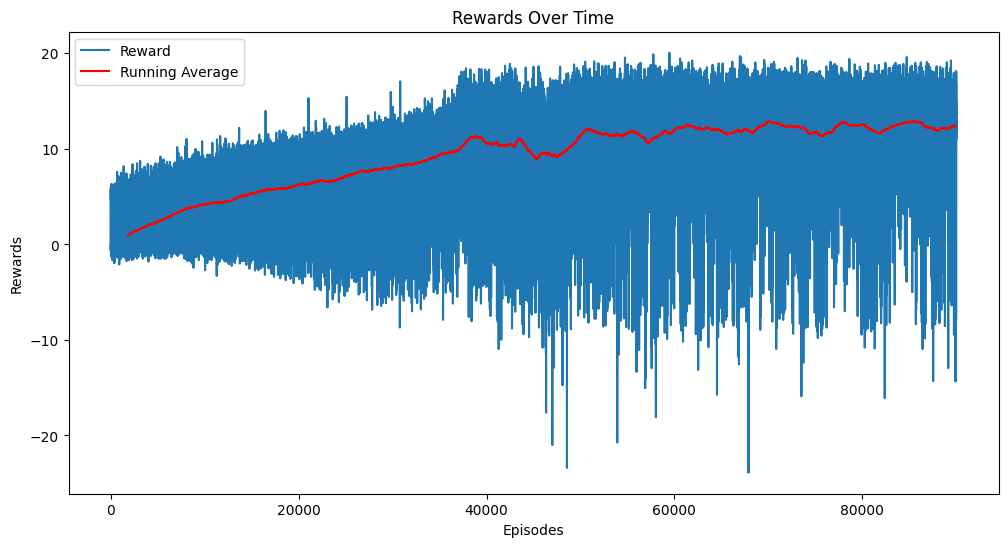

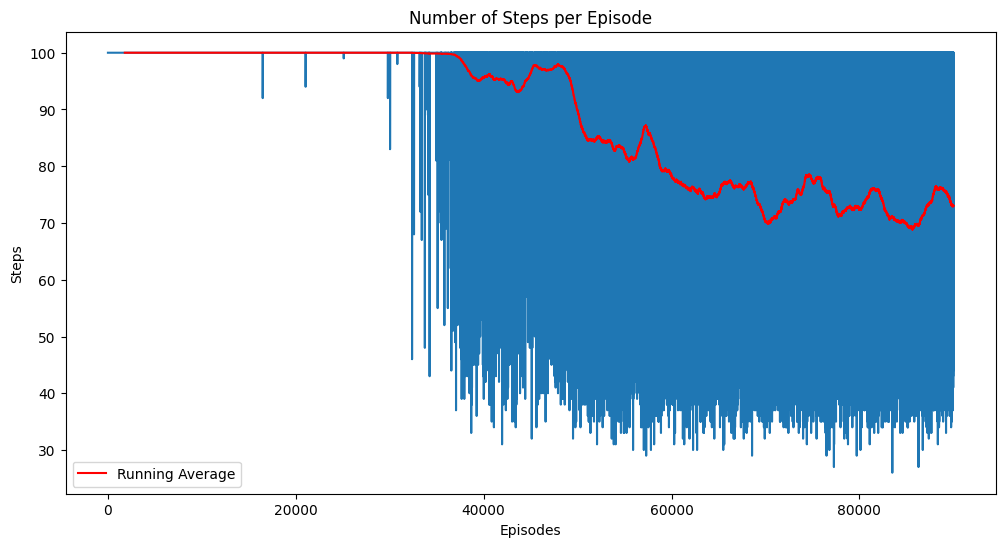

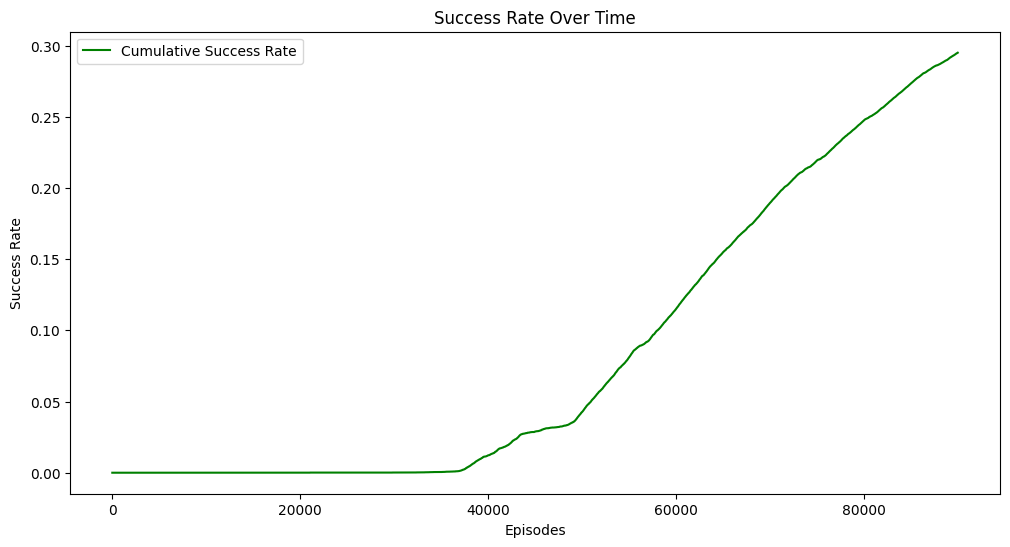

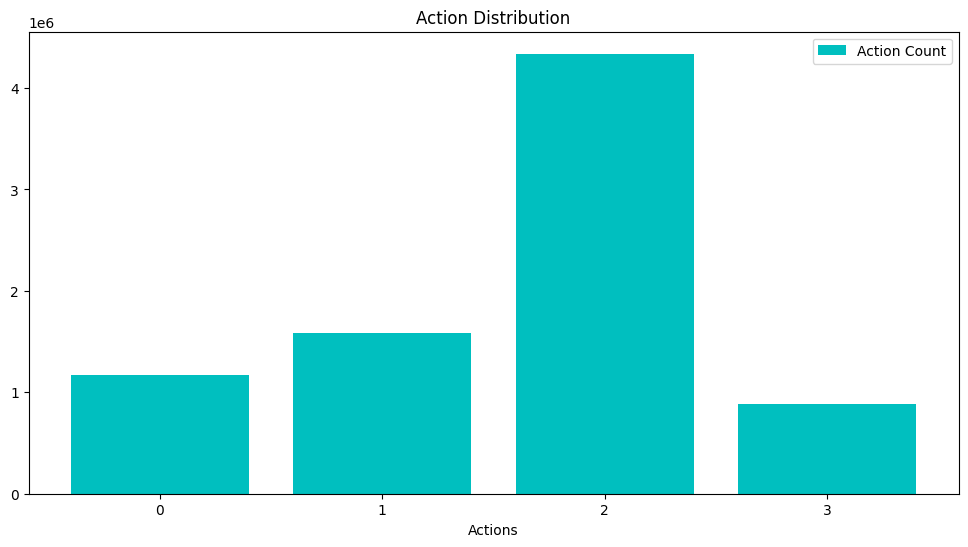

In [ ]:
DDDQN_agent.load_backup("backup_ep_90000.pkl")

DDDQN_agent.train()
DDDQN_agent.save_model("/content/drive/MyDrive/MLDS/RL/final/train_6Rooms_90000.pkl")
train_analysis(DDDQN_agent.total_rewards, DDDQN_agent.total_steps, DDDQN_agent.success_rates,DDDQN_agent.action_counts, training_episodes)

In [ ]:
env = gymnasium.make("MiniGrid-MultiRoom-N6-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)

test_agent = DuelingDoubleDQNAgent(env, learning_rate = 0.0005, gamma = 0.95, epsilon_decay = 0.99995, training_episodes = 80000)

test_agent.load_model("/content/drive/MyDrive/MLDS/RL/final/train_6Rooms_90000.pkl")

test_agent.test_model(num_episodes = 1, video_name = 'train_6Rooms_80000')

video_filename = 'test_model_train_6Rooms_80000.mp4'
embed_mp4(video_filename)

Model parameters loaded successfully from /content/drive/MyDrive/MLDS/RL/final/train_6Rooms_90000.pkl
Episode 0 - Reward: 0.6025, Steps 53
--------------------------------------------------
Number of success episodes: 1 out of 1


# Test

## 2 Small Rooms Agent

In [ ]:
# Test the agent on 2 small rooms env

env = gymnasium.make("MiniGrid-MultiRoom-N2-S4-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)

test_agent = DuelingDoubleDQNAgent(env, learning_rate = 0.0005, gamma = 0.95, epsilon_decay = 0.99995, training_episodes = 60000)

test_agent.load_model("/content/drive/MyDrive/MLDS/RL/final/train_2SmallRooms_60000.pkl")

test_agent.test_model(num_episodes = 10, video_name = 'train_2SmallRooms_60000')

video_filename = 'test_model_train_2SmallRooms_60000.mp4'
embed_mp4(video_filename)

Model parameters loaded successfully from /content/drive/MyDrive/MLDS/RL/final/train_2SmallRooms_60000.pkl
Episode 0 - Reward: 0.865, Steps 6
--------------------------------------------------
Episode 1 - Reward: 0.82, Steps 8
--------------------------------------------------
Episode 2 - Reward: 0.865, Steps 6
--------------------------------------------------
Episode 3 - Reward: 0.82, Steps 8
--------------------------------------------------
Episode 4 - Reward: 0.82, Steps 8
--------------------------------------------------
Episode 5 - Reward: 0.775, Steps 10
--------------------------------------------------
Episode 6 - Reward: 0.82, Steps 8
--------------------------------------------------
Episode 7 - Reward: 0.8425, Steps 7
--------------------------------------------------
Episode 8 - Reward: 0.82, Steps 8
--------------------------------------------------
Episode 9 - Reward: 0.91, Steps 4
--------------------------------------------------
Number of success episodes: 10 out of

In [ ]:
# Test the agent on 6 small rooms env

env = gymnasium.make("MiniGrid-MultiRoom-N4-S5-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)

test_agent = DuelingDoubleDQNAgent(env, learning_rate = 0.0005, gamma = 0.95, epsilon_decay = 0.99995, training_episodes = 60000)

test_agent.load_model("/content/drive/MyDrive/MLDS/RL/final/train_2SmallRooms_60000.pkl")

test_agent.test_model(num_episodes = 10, video_name = 'train_2SmallRooms_60000')

video_filename = 'test_model_train_2SmallRooms_60000.mp4'
embed_mp4(video_filename)

Model parameters loaded successfully from /content/drive/MyDrive/MLDS/RL/final/train_2SmallRooms_60000.pkl
Episode 0 - Reward: 0, Steps 120
--------------------------------------------------
Episode 1 - Reward: 0, Steps 120
--------------------------------------------------
Episode 2 - Reward: 0, Steps 120
--------------------------------------------------
Episode 3 - Reward: 0, Steps 120
--------------------------------------------------
Episode 4 - Reward: 0, Steps 120
--------------------------------------------------
Episode 5 - Reward: 0, Steps 120
--------------------------------------------------
Episode 6 - Reward: 0, Steps 120
--------------------------------------------------
Episode 7 - Reward: 0, Steps 120
--------------------------------------------------
Episode 8 - Reward: 0, Steps 120
--------------------------------------------------
Episode 9 - Reward: 0, Steps 120
--------------------------------------------------
Number of success episodes: 0 out of 10


## 6 Small Rooms Agent

In [ ]:
# Test the agent on 6 small rooms env

env = gymnasium.make("MiniGrid-MultiRoom-N4-S5-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)

test_agent = DuelingDoubleDQNAgent(env, learning_rate = 0.0005, gamma = 0.95, epsilon_decay = 0.99995, training_episodes = 60000)

test_agent.load_model("/content/drive/MyDrive/MLDS/RL/final/train_6SmallRooms_80000.pkl")

test_agent.test_model(num_episodes = 10, video_name = 'train_6SmallRooms_80000')

video_filename = 'test_model_train_6SmallRooms_80000.mp4'
embed_mp4(video_filename)

Model parameters loaded successfully from /content/drive/MyDrive/MLDS/RL/final/train_6SmallRooms_80000.pkl
Episode 0 - Reward: 0.7375, Steps 35
--------------------------------------------------
Episode 1 - Reward: 0.745, Steps 34
--------------------------------------------------
Episode 2 - Reward: 0.7675, Steps 31
--------------------------------------------------
Episode 3 - Reward: 0.7150000000000001, Steps 38
--------------------------------------------------
Episode 4 - Reward: 0.7525, Steps 33
--------------------------------------------------
Episode 5 - Reward: 0.7075, Steps 39
--------------------------------------------------
Episode 6 - Reward: 0.775, Steps 30
--------------------------------------------------
Episode 7 - Reward: 0.73, Steps 36
--------------------------------------------------
Episode 8 - Reward: 0.7375, Steps 35
--------------------------------------------------
Episode 9 - Reward: 0.7975, Steps 27
--------------------------------------------------
Numbe

In [ ]:
# Test the agent on 6 rooms env

env = gymnasium.make("MiniGrid-MultiRoom-N6-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)

test_agent = DuelingDoubleDQNAgent(env, learning_rate = 0.0005, gamma = 0.95, epsilon_decay = 0.99995, training_episodes = 60000)

test_agent.load_model("/content/drive/MyDrive/MLDS/RL/final/train_6SmallRooms_80000.pkl")

test_agent.test_model(num_episodes = 10, video_name = 'train_6SmallRooms_80000')

video_filename = 'test_model_train_6SmallRooms_80000.mp4'
embed_mp4(video_filename)

Model parameters loaded successfully from /content/drive/MyDrive/MLDS/RL/final/train_6SmallRooms_80000.pkl
Episode 0 - Reward: 0, Steps 120
--------------------------------------------------
Episode 1 - Reward: 0, Steps 120
--------------------------------------------------
Episode 2 - Reward: 0, Steps 120
--------------------------------------------------
Episode 3 - Reward: 0, Steps 120
--------------------------------------------------
Episode 4 - Reward: 0, Steps 120
--------------------------------------------------
Episode 5 - Reward: 0, Steps 120
--------------------------------------------------
Episode 6 - Reward: 0, Steps 120
--------------------------------------------------
Episode 7 - Reward: 0, Steps 120
--------------------------------------------------
Episode 8 - Reward: 0, Steps 120
--------------------------------------------------
Episode 9 - Reward: 0, Steps 120
--------------------------------------------------
Number of success episodes: 0 out of 10


## 6 Rooms Agent

In [ ]:
# Test the agent on 6 rooms env

env = gymnasium.make("MiniGrid-MultiRoom-N6-v0", render_mode=render_mode, highlight=highlight)
env = RGBImgPartialObsWrapper(env)
env = ImgObsWrapper(env)

test_agent = DuelingDoubleDQNAgent(env, learning_rate = 0.0005, gamma = 0.95, epsilon_decay = 0.99995, training_episodes = 60000)

test_agent.load_model("/content/drive/MyDrive/MLDS/RL/final/train_6Rooms_90000.pkl")

test_agent.test_model(num_episodes = 10, video_name = 'train_6Rooms_90000')

video_filename = 'test_model_train_6Rooms_90000.mp4'
embed_mp4(video_filename)

Model parameters loaded successfully from /content/drive/MyDrive/MLDS/RL/final/train_6Rooms_90000.pkl
Episode 0 - Reward: 0, Steps 120
--------------------------------------------------
Episode 1 - Reward: 0.67, Steps 44
--------------------------------------------------
Episode 2 - Reward: 0.61, Steps 52
--------------------------------------------------
Episode 3 - Reward: 0.49749999999999994, Steps 67
--------------------------------------------------
Episode 4 - Reward: 0.6174999999999999, Steps 51
--------------------------------------------------
Episode 5 - Reward: 0.6325000000000001, Steps 49
--------------------------------------------------
Episode 6 - Reward: 0.7150000000000001, Steps 38
--------------------------------------------------
Episode 7 - Reward: 0.52, Steps 64
--------------------------------------------------
Episode 8 - Reward: 0.58, Steps 56
--------------------------------------------------
Episode 9 - Reward: 0.595, Steps 54
---------------------------------